# Local Validation & Error Analysis

This notebook performs full local evaluation. It first executes `predict.py` to run recursive prediction on the validation set, and then visualizes the errors.


In [1]:
EXP_NAME = 'feature-delta-anchor'
MODEL_DIR = f'../model/{EXP_NAME}'

In [2]:
import sys

sys.path.insert(0, '../src')

from predict import predict_validation

# Gọi dự đoán và chỉ định thẳng đường dẫn lưu file chính xác
predict_validation(
    data_dir='../data', 
    model_dir=MODEL_DIR, 
    output='../data/validation_predictions.csv'
)

Predicting validation wells:   0%|          | 0/154 [00:00<?, ?it/s]

Local RMSE: 12.7890


,id,tvt,TVT,well_id
0,e161bd0c_1864,12218.582354,12218.59,e161bd0c
1,e161bd0c_1865,12218.586415,12218.59,e161bd0c
2,e161bd0c_1866,12218.590275,12218.59,e161bd0c
3,e161bd0c_1867,12218.591782,12218.59,e161bd0c
4,e161bd0c_1868,12218.594633,12218.60,e161bd0c
...,...,...,...,...
755486,9ffce529_6670,12053.355216,12032.86,9ffce529
755487,9ffce529_6671,12053.357900,12032.86,9ffce529
755488,9ffce529_6672,12053.360776,12032.87,9ffce529
755489,9ffce529_6673,12053.363497,12032.88,9ffce529


In [3]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, '../src')
from dataset import load_well

sns.set_theme(style="whitegrid")


## 1. Load Validation Predictions
Read the `validation_predictions.csv` file generated by `predict.py`.


In [4]:
PRED_PATH = Path('../data/validation_predictions.csv')
DATA_DIR = Path('../data')

if not PRED_PATH.exists():
    raise FileNotFoundError(f"Missing {PRED_PATH}. Run inference above first.")

preds = pd.read_csv(PRED_PATH)
preds['error'] = preds['tvt'] - preds['TVT']
preds['abs_error'] = preds['error'].abs()

print(f"Loaded {len(preds)} prediction rows across {preds['well_id'].nunique()} validation wells.")
rmse_overall = np.sqrt((preds['error'] ** 2).mean())
print(f"Overall Validation RMSE: {rmse_overall:.4f}")


Loaded 755491 prediction rows across 154 validation wells.
Overall Validation RMSE: 12.7890


## 2. Cumulative Error Drift along Wellbore (MD)
Plot the error drift over the measured depth (MD) for a few sample validation wells.


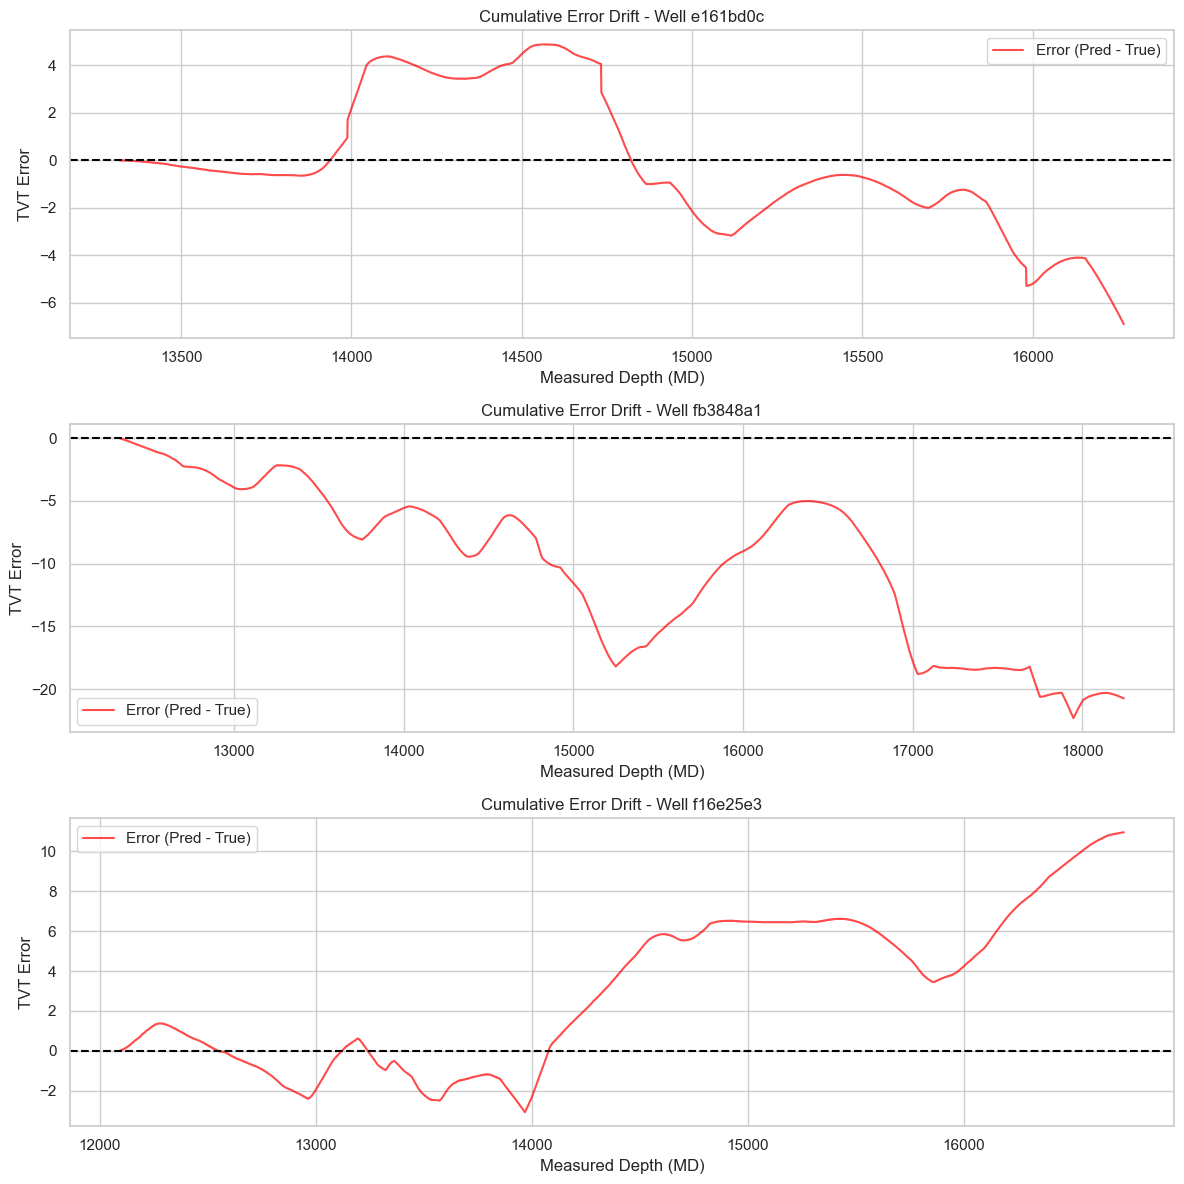

In [5]:
sample_wells = preds['well_id'].unique()[:3]

fig, axes = plt.subplots(len(sample_wells), 1, figsize=(12, 4 * len(sample_wells)), sharex=False)
if len(sample_wells) == 1: axes = [axes]

for ax, well_id in zip(axes, sample_wells):
    well_data = preds[preds['well_id'] == well_id].copy()
    well = load_well(DATA_DIR, "train", well_id)
    
    # Merge with horizontal data to get MD
    well_data['row_index'] = well_data['id'].apply(lambda x: int(str(x).split('_')[-1]))
    well_data = well_data.merge(well.horizontal[['row_index', 'MD']], on='row_index')
    well_data = well_data.sort_values('MD')
    
    ax.plot(well_data['MD'], well_data['error'], label='Error (Pred - True)', color='red', alpha=0.7)
    ax.axhline(0, color='black', linestyle='--')
    ax.set_title(f'Cumulative Error Drift - Well {well_id}')
    ax.set_xlabel('Measured Depth (MD)')
    ax.set_ylabel('TVT Error')
    ax.legend()

plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/cumulative_error_drift.png', bbox_inches='tight', dpi=300)
plt.show()


## 3. RMSE by Geological Formation
Match predictions to the nearest geological formation in the typewell to identify blind spots.


C:\Users\MSl\AppData\Local\Temp\ipykernel_23204\763447406.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=geo_rmse, y='Geology', x='rmse', palette='viridis')


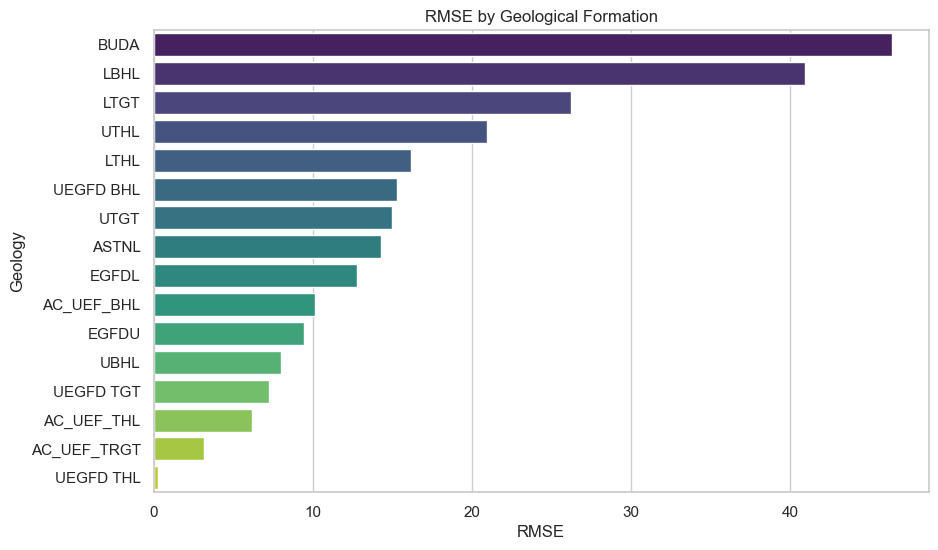

,Geology,rmse,count
4,BUDA,46.368012,209
7,LBHL,40.894582,316
8,LTGT,26.187600,441
15,UTHL,20.908997,1070
9,LTHL,16.139689,5938
11,UEGFD BHL,15.298954,1148
14,UTGT,14.970570,14467
3,ASTNL,14.291814,29386
5,EGFDL,12.778880,653411
0,AC_UEF_BHL,10.144318,2978


In [6]:
def get_geology_rmse():
    records = []
    for well_id, group in preds.groupby('well_id'):
        well = load_well(DATA_DIR, "train", well_id)
        if 'Geology' not in well.typewell.columns:
            continue
            
        tw = well.typewell[['TVT', 'Geology']].dropna(subset=['TVT', 'Geology']).sort_values('TVT')
        if len(tw) == 0: continue
        
        tw_tvt = tw['TVT'].values
        tw_geo = tw['Geology'].values
        
        true_tvt = group['TVT'].values
        valid = np.isfinite(true_tvt)
        
        if not np.any(valid): continue
        
        # Find nearest TVT in typewell for each valid row
        pos = np.searchsorted(tw_tvt, true_tvt[valid], side="left")
        right = np.clip(pos, 0, len(tw_tvt) - 1)
        left = np.clip(pos - 1, 0, len(tw_tvt) - 1)
        use_left = np.abs(true_tvt[valid] - tw_tvt[left]) <= np.abs(true_tvt[valid] - tw_tvt[right])
        nearest = np.where(use_left, left, right)
        
        geology_labels = tw_geo[nearest]
        
        for geo, err in zip(geology_labels, group['error'].values[valid]):
            records.append({'Geology': geo, 'sq_error': err**2})
            
    if not records:
        print("No geology data available to match.")
        return
        
    geo_df = pd.DataFrame(records)
    geo_rmse = geo_df.groupby('Geology').agg(
        rmse=('sq_error', lambda x: np.sqrt(x.mean())),
        count=('sq_error', 'count')
    ).reset_index()
    
    geo_rmse = geo_rmse[geo_rmse['count'] > 10].sort_values('rmse', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=geo_rmse, y='Geology', x='rmse', palette='viridis')
    plt.title('RMSE by Geological Formation')
    plt.xlabel('RMSE')
    plt.ylabel('Geology')
    plt.savefig(f'{MODEL_DIR}/rmse_by_geology.png', bbox_inches='tight', dpi=300)
    plt.show()
    
    return geo_rmse

get_geology_rmse()


## 4. Gamma Ray Signal Overlay Debugging
Visualize the alignment between the horizontal GR signal and the typewell GR signal at the predicted/true TVT.


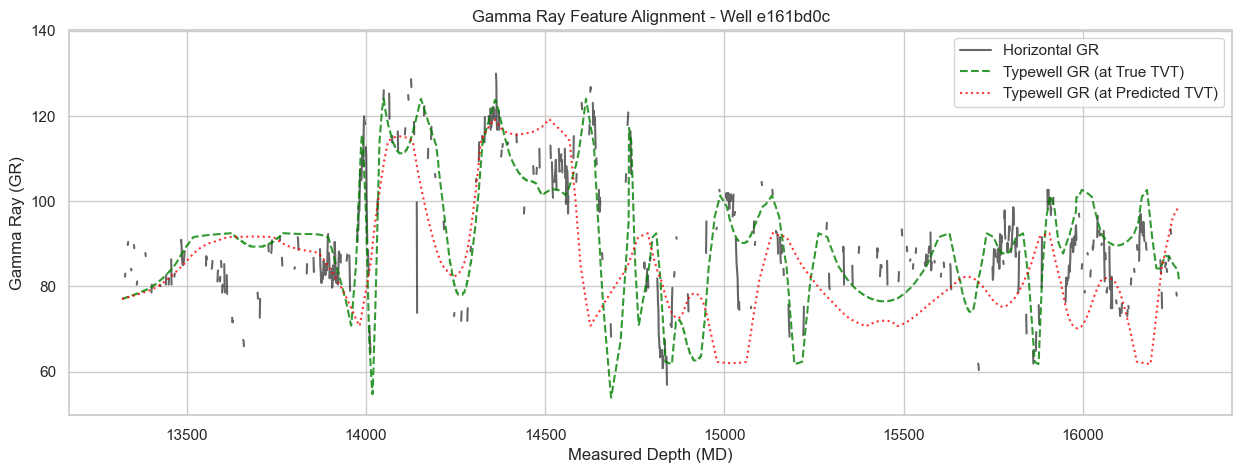

In [7]:
well_id = sample_wells[0]
well = load_well(DATA_DIR, "train", well_id)
group = preds[preds['well_id'] == well_id].copy()
group['row_index'] = group['id'].apply(lambda x: int(str(x).split('_')[-1]))
group = group.merge(well.horizontal[['row_index', 'MD', 'GR']], on='row_index').sort_values('MD')

tw = well.typewell[['TVT', 'GR']].dropna(subset=['TVT']).sort_values('TVT')
tw_tvt = tw['TVT'].values
tw_gr = tw['GR'].values

# Interpolate Typewell GR at True TVT
true_tvt = group['TVT'].values
true_tw_gr = np.interp(true_tvt, tw_tvt, tw_gr)

# Interpolate Typewell GR at Predicted TVT
pred_tvt = group['tvt'].values
pred_tw_gr = np.interp(pred_tvt, tw_tvt, tw_gr)

plt.figure(figsize=(15, 5))
plt.plot(group['MD'], group['GR'], label='Horizontal GR', color='black', alpha=0.6)
plt.plot(group['MD'], true_tw_gr, label='Typewell GR (at True TVT)', color='green', alpha=0.8, linestyle='--')
plt.plot(group['MD'], pred_tw_gr, label='Typewell GR (at Predicted TVT)', color='red', alpha=0.8, linestyle=':')
plt.title(f'Gamma Ray Feature Alignment - Well {well_id}')
plt.xlabel('Measured Depth (MD)')
plt.ylabel('Gamma Ray (GR)')
plt.legend()
plt.savefig(f'{MODEL_DIR}/gamma_ray_alignment.png', bbox_inches='tight', dpi=300)
plt.show()
